# Compare Trained Go/No-Go Networks

This notebook loads the trained low-rank RNN, full-rank RNN, and LSTM from `homework_CN/outputs`, tests them on the same 3-context Go/No-Go task, and compares:

- training curves and final performance
- final scalar outputs for every context/stimulus rule
- output trajectories across the 10 timestep trial
- hidden-state PCA trajectories as a first look at latent dynamics

Test design: 3 repeated trials for each of the 6 task cases: `3 contexts x 2 stimuli x 3 repeats = 18 trials`.

## 1. Setup

The notebook is written to run either from the project root or from inside `homework_CN`.

In [8]:
from pathlib import Path
import sys
import json
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch as T
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Resolve paths robustly for either project-root or homework_CN working directories.
CWD = Path.cwd()
if (CWD / "train_context_gonogo.py").exists() and (CWD / "outputs").exists():
    HOMEWORK_DIR = CWD
else:
    HOMEWORK_DIR = CWD / "homework_CN"

OUTPUT_DIR = HOMEWORK_DIR / "outputs"
sys.path.insert(0, str(HOMEWORK_DIR))

from low_rank_rnn import LowRankRNN
from full_rank_rnn import FullRankRNN
from lstm_rnn import LSTMRNN
from train_context_gonogo import ContextGoNoGoTask

DEVICE = T.device("cuda" if T.cuda.is_available() else "cpu")
print("HOMEWORK_DIR:", HOMEWORK_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DEVICE:", DEVICE)

HOMEWORK_DIR: /Users/utsai/Documents/tsai_project/homework_CN
OUTPUT_DIR: /Users/utsai/Documents/tsai_project/homework_CN/outputs
DEVICE: cpu


## 2. Load Trained Networks

The loader reads the checkpoint metadata and reconstructs each architecture with the same `hidden_size`, `rank`, `seq_len`, and `alpha` used during training.

In [9]:
MODEL_FILES = {
    "low_rank": OUTPUT_DIR / "low_rank_final_model.pt",
    "full_rank": OUTPUT_DIR / "full_rank_final_model.pt",
    "lstm": OUTPUT_DIR / "lstm_final_model.pt",
}


def build_model(model_type, args):
    common = dict(input_size=5, hidden_size=args.hidden_size, output_size=1)
    if model_type == "low_rank":
        return LowRankRNN(rank=args.rank, alpha=args.alpha, **common)
    if model_type == "full_rank":
        return FullRankRNN(alpha=args.alpha, **common)
    if model_type == "lstm":
        return LSTMRNN(**common)
    raise ValueError(f"Unknown model type: {model_type}")


def load_trained_model(path):
    ckpt = T.load(path, map_location=DEVICE)
    args = SimpleNamespace(**ckpt["args"])
    model_type = ckpt["model_type"]
    model = build_model(model_type, args).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, args, ckpt

models = {}
model_args = {}
checkpoints = {}
for name, path in MODEL_FILES.items():
    model, args, ckpt = load_trained_model(path)
    models[name] = model
    model_args[name] = args
    checkpoints[name] = ckpt
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name:9s} | hidden={args.hidden_size} rank={args.rank} seq_len={args.seq_len} alpha={args.alpha} trainable={n_trainable:,}")

low_rank  | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=2,048
full_rank | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=67,072
lstm      | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=269,569


## 3. Compare Training Curves

These curves come from the saved `*_metrics.json` files created during training.

In [10]:
def load_metrics(name):
    with (OUTPUT_DIR / f"{name}_metrics.json").open() as f:
        return json.load(f)

metrics = {name: load_metrics(name) for name in models}
summary_rows = []
for name, data in metrics.items():
    args = model_args[name]
    summary_rows.append({
        "model": name,
        "steps": args.steps,
        "hidden_size": args.hidden_size,
        "rank": args.rank if name == "low_rank" else None,
        "repeats_per_case": args.repeats_per_case,
        "final_accuracy": data["final_accuracy"],
        "final_mse": data["final_mse"],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df

,model,steps,hidden_size,rank,repeats_per_case,final_accuracy,final_mse
0,low_rank,10000,256,1.0,4,1.0,6.347515e-13
1,full_rank,5000,256,NaN,4,1.0,4.249175e-07
2,lstm,5000,256,NaN,4,1.0,6.766134e-10


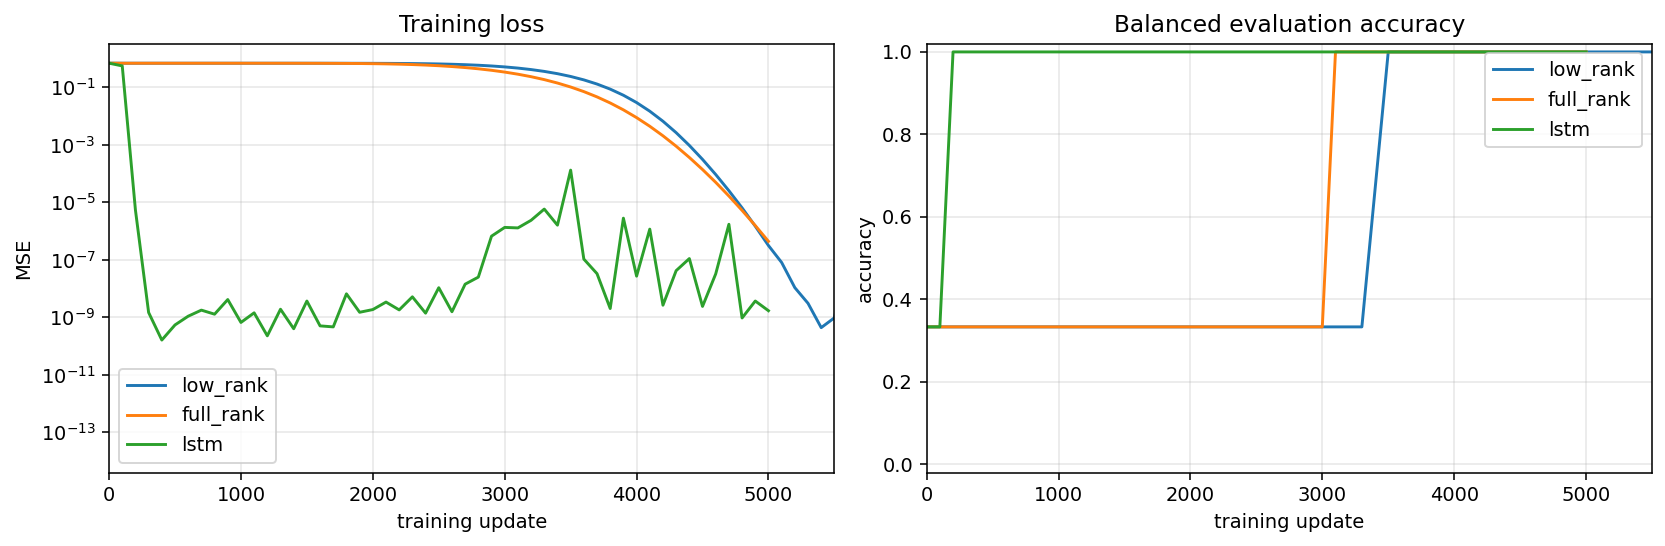

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)

for name, data in metrics.items():
    hist = data["history"]
    axes[0].plot(hist["step"], hist["loss"], label=name)
    axes[1].plot(hist["step"], hist["accuracy"], label=name)

axes[0].set_title("Training loss")
axes[0].set_xlabel("training update")
axes[0].set_ylabel("MSE")
axes[0].set_xlim(0, 5500)
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Balanced evaluation accuracy")
axes[1].set_xlabel("training update")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlim(0, 5500)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Build a Small Test Set

We test 3 repeated trials per context/stimulus pair. Because the task and networks are deterministic, repeated trials should produce identical outputs; keeping repeats makes the test design explicit and easy to explain.

In [12]:
task = ContextGoNoGoTask(seq_len=model_args["low_rank"].seq_len)
TEST_REPEATS_PER_CASE = 3
inputs, targets, contexts, stimuli = task.make_balanced_batch(TEST_REPEATS_PER_CASE, DEVICE)

case_df = pd.DataFrame({
    "trial": np.arange(len(contexts.cpu())),
    "context": contexts.cpu().numpy(),
    "stimulus": stimuli.cpu().numpy().astype(int),
    "target": targets.squeeze(1).cpu().numpy().astype(int),
})
case_df.head(18)

,trial,context,stimulus,target
0,0,0,-1,0
1,1,0,-1,0
2,2,0,-1,0
3,3,0,1,0
4,4,0,1,0
5,5,0,1,0
6,6,1,-1,-1
7,7,1,-1,-1
8,8,1,-1,-1
9,9,1,1,1


## 5. Output and Performance on the Test Set

The networks produce a scalar output. For behavioral accuracy, scalar outputs are discretized into `-1`, `0`, `+1` using thresholds at `-1/3` and `+1/3`.

In [13]:
@T.no_grad()
def run_test_set(model):
    outputs, states = model(inputs, return_states=True)
    final_output = outputs[:, -1, :]
    pred = task.discretize(final_output)
    acc = (task.value_to_index(pred) == task.value_to_index(targets)).float().mean().item()
    mse = F.mse_loss(final_output, targets).item()
    return outputs.cpu(), states.cpu(), final_output.cpu(), pred.cpu(), acc, mse

results = {}
for name, model in models.items():
    outputs, states, final_output, pred, acc, mse = run_test_set(model)
    results[name] = {
        "outputs": outputs,
        "states": states,
        "final_output": final_output,
        "prediction": pred,
        "accuracy": acc,
        "mse": mse,
    }
    print(f"{name:9s} | test accuracy={acc:.3f} | test MSE={mse:.3e}")

low_rank  | test accuracy=1.000 | test MSE=6.516e-13
full_rank | test accuracy=1.000 | test MSE=4.249e-07
lstm      | test accuracy=1.000 | test MSE=2.202e-09


In [14]:
rows = []
for name, res in results.items():
    for i in range(len(case_df)):
        rows.append({
            "model": name,
            "trial": i,
            "context": int(contexts[i].cpu()),
            "stimulus": int(stimuli[i].cpu()),
            "target": int(targets[i].item()),
            "raw_output": float(res["final_output"][i].item()),
            "prediction": int(res["prediction"][i].item()),
        })
output_df = pd.DataFrame(rows)
output_df.head(18)

,model,trial,context,stimulus,target,raw_output,prediction
0,low_rank,0,0,-1,0,1.579523e-06,0
1,low_rank,1,0,-1,0,1.579523e-06,0
2,low_rank,2,0,-1,0,1.579523e-06,0
3,low_rank,3,0,1,0,3.278255e-07,0
4,low_rank,4,0,1,0,3.278255e-07,0
5,low_rank,5,0,1,0,3.278255e-07,0
6,low_rank,6,1,-1,-1,-9.999995e-01,-1
7,low_rank,7,1,-1,-1,-9.999995e-01,-1
8,low_rank,8,1,-1,-1,-9.999995e-01,-1
9,low_rank,9,1,1,1,1.000000e+00,1


In [15]:
# Average repeated trials for a compact 6-case comparison.
case_mean = (
    output_df
    .groupby(["model", "context", "stimulus", "target"], as_index=False)
    .agg(raw_output=("raw_output", "mean"), prediction=("prediction", "first"))
)
case_mean

,model,context,stimulus,target,raw_output,prediction
0,full_rank,0,-1,0,-2.067387e-04,0
1,full_rank,0,1,0,2.537668e-04,0
2,full_rank,1,-1,-1,-9.990601e-01,-1
3,full_rank,1,1,1,9.990821e-01,1
4,full_rank,2,-1,1,9.994161e-01,1
5,full_rank,2,1,-1,-9.993871e-01,-1
6,low_rank,0,-1,0,1.579523e-06,0
7,low_rank,0,1,0,3.278255e-07,0
8,low_rank,1,-1,-1,-9.999995e-01,-1
9,low_rank,1,1,1,1.000000e+00,1


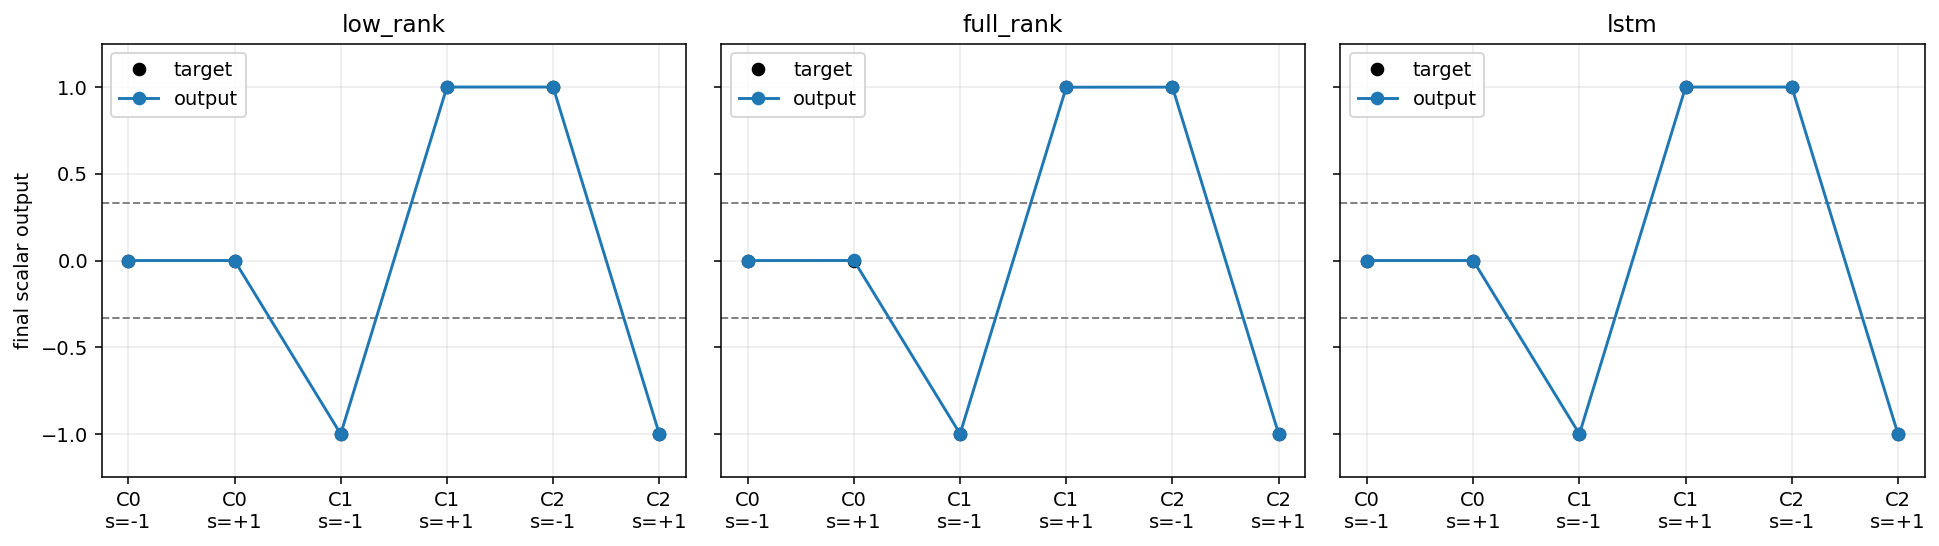

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, dpi=140)
case_order = [(c, s) for c in range(3) for s in (-1, 1)]
x = np.arange(len(case_order))
labels = [f"C{c}\ns={s:+d}" for c, s in case_order]

target_values = []
for c, s in case_order:
    target_values.append(case_mean[(case_mean.context == c) & (case_mean.stimulus == s)].target.iloc[0])

for ax, name in zip(axes, models.keys()):
    sub = case_mean[case_mean.model == name]
    y = []
    for c, s in case_order:
        y.append(sub[(sub.context == c) & (sub.stimulus == s)].raw_output.iloc[0])
    ax.axhline(1/3, color="grey", ls="--", lw=1)
    ax.axhline(-1/3, color="grey", ls="--", lw=1)
    ax.plot(x, target_values, "ko", label="target")
    ax.plot(x, y, "o-", label="output")
    ax.set_title(name)
    ax.set_xticks(x, labels)
    ax.set_ylim(-1.25, 1.25)
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[0].set_ylabel("final scalar output")
plt.tight_layout()
plt.show()

## 6. Output Trajectories Across the Trial

These plots show the scalar readout at every timestep. The final timestep is the behavioral decision point because that is when the go cue is present.

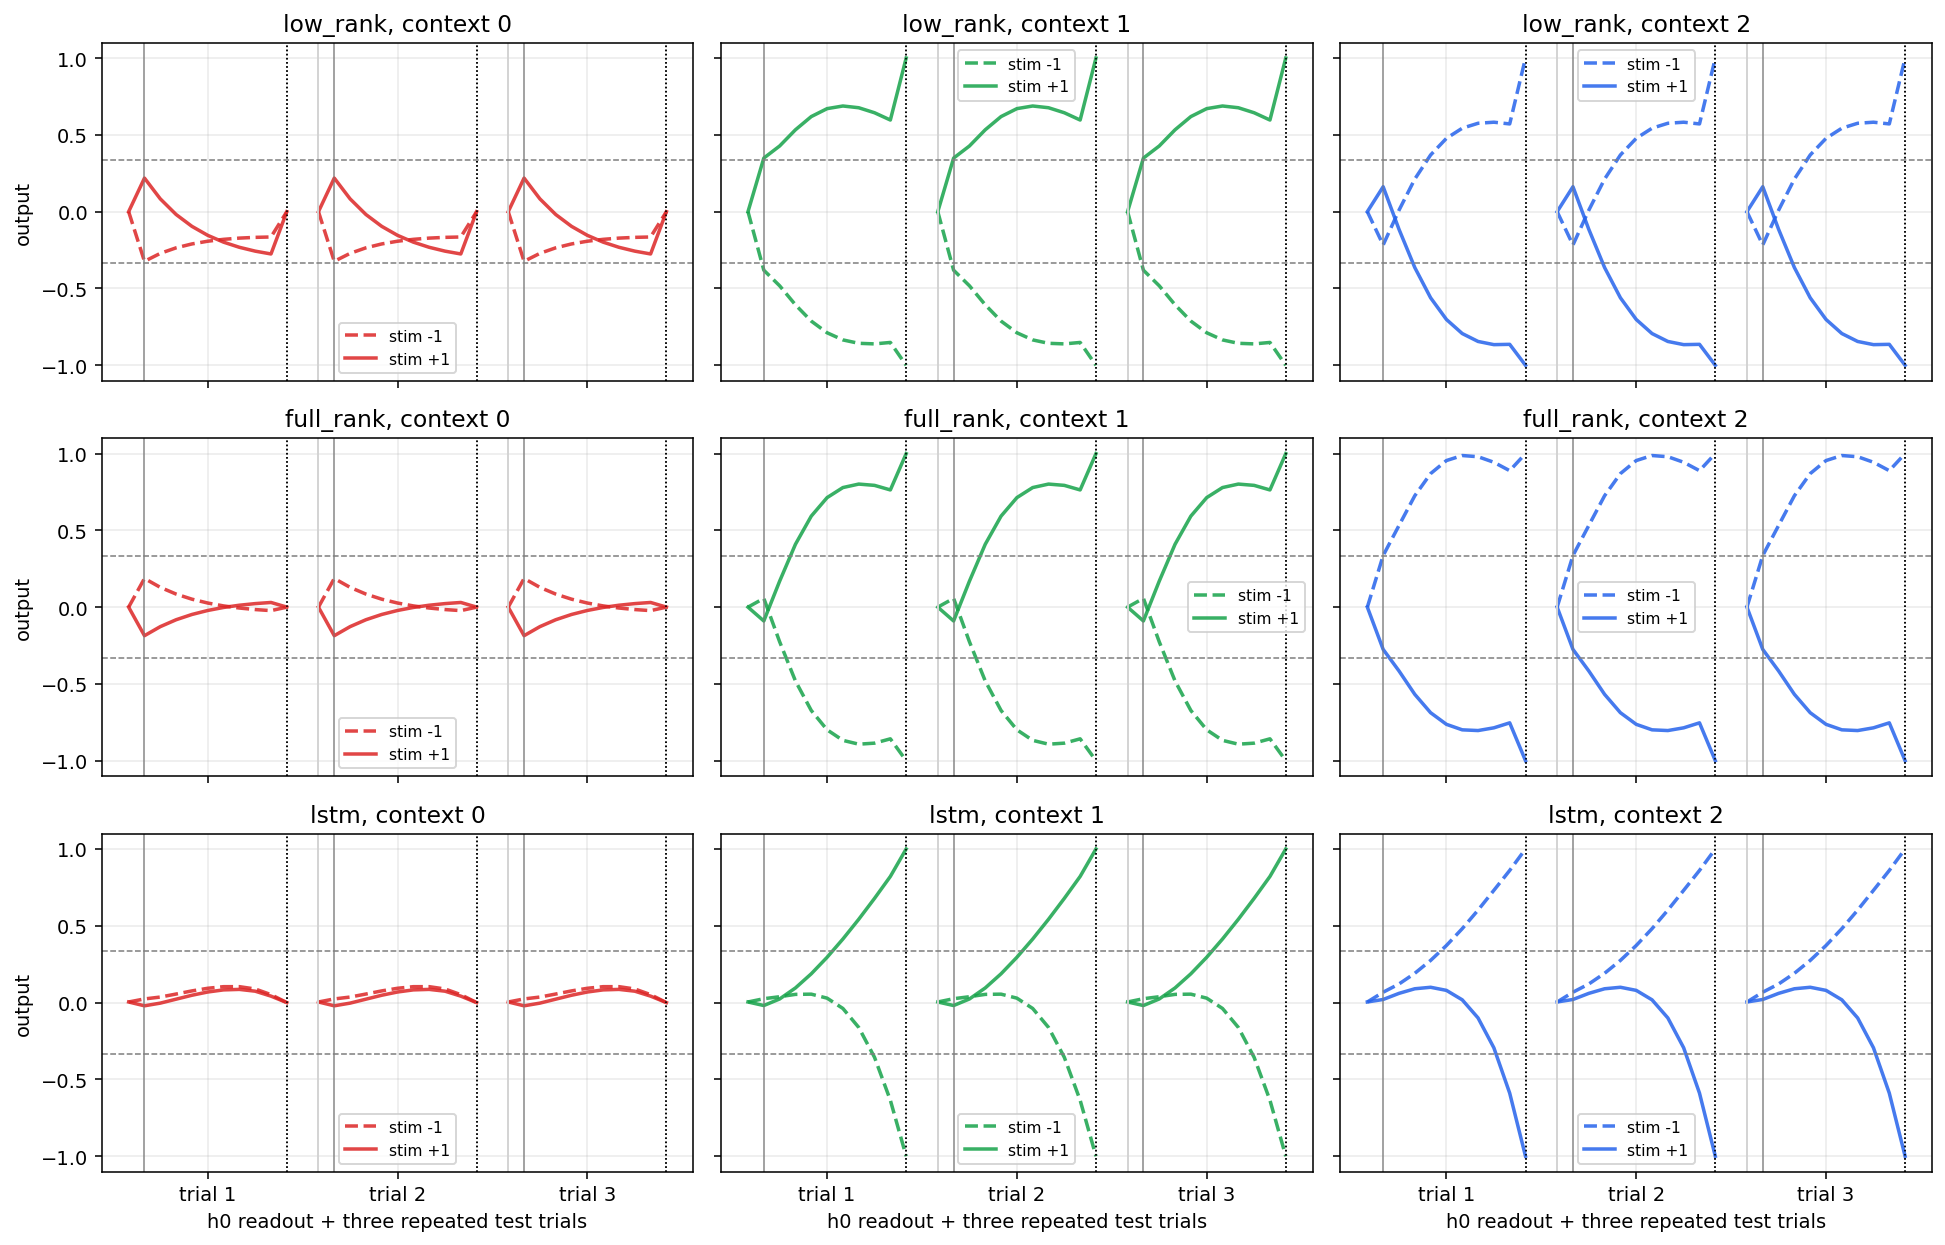

In [20]:
colors = {0: "#dc2626", 1: "#16a34a", 2: "#2563eb"}
linestyles = {-1: "--", 1: "-"}

def initial_readout(model, model_name):
    """Readout from the default initial state h0 before any input."""
    with T.no_grad():
        if model_name == "lstm":
            # For LSTM, default hidden/cell states are zeros.
            h0 = T.zeros(1, 1, model.hidden_size, device=DEVICE)
            y0 = model.readout(h0.squeeze(0))
            return float(y0.squeeze().cpu())

        # For low-rank and full-rank RNNs, read out tanh(h0).
        h0 = model.h0.to(DEVICE)
        rates = T.tanh(h0)
        y0 = rates @ model.W_out.t()
        return float(y0.squeeze().cpu())


trial_len = task.seq_len
gap = 1

# Add one pre-trial timestep at x=-1 for h0 readout.
pre_len = 1
plot_trial_len = trial_len + pre_len
trial_stride = plot_trial_len + gap

trial_x = np.arange(-1, trial_len)
real_trial_x = np.arange(trial_len)
trial_centers = [
    (trial_x.mean() + k * trial_stride)
    for k in range(TEST_REPEATS_PER_CASE)
]

fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True, sharey=True, dpi=140)

for row, (name, res) in enumerate(results.items()):
    outputs = res["outputs"].squeeze(-1).numpy()
    y0 = initial_readout(models[name], name)

    for context_id in range(3):
        ax = axes[row, context_id]

        for stimulus in (-1, 1):
            mask = (
                (contexts.cpu().numpy() == context_id)
                & (stimuli.cpu().numpy() == stimulus)
            )

            trial_indices = np.where(mask)[0][:TEST_REPEATS_PER_CASE]

            for repeat_i, trial_idx in enumerate(trial_indices):
                x = trial_x + repeat_i * trial_stride

                # Prepend h0 readout at t=-1.
                y = np.concatenate([[y0], outputs[trial_idx]])

                label = f"stim {stimulus:+d}" if repeat_i == 0 else None

                ax.plot(
                    x,
                    y,
                    color=colors[context_id],
                    ls=linestyles[stimulus],
                    lw=1.8,
                    alpha=0.85,
                    label=label,
                )

                # Mark stimulus onset t=0.
                ax.axvline(
                    0 + repeat_i * trial_stride,
                    color="grey",
                    ls="-",
                    lw=0.8,
                    alpha=0.6,
                )

                # Mark go cue / decision timestep.
                ax.axvline(
                    task.go_cue_t + repeat_i * trial_stride,
                    color="black",
                    ls=":",
                    lw=0.8,
                )

        for repeat_i in range(1, TEST_REPEATS_PER_CASE):
            ax.axvline(
                repeat_i * trial_stride - gap,
                color="lightgrey",
                lw=1.0,
            )

        ax.axhline(1 / 3, color="grey", ls="--", lw=0.8)
        ax.axhline(-1 / 3, color="grey", ls="--", lw=0.8)

        ax.set_title(f"{name}, context {context_id}")
        ax.set_xticks(
            trial_centers,
            [f"trial {i + 1}" for i in range(TEST_REPEATS_PER_CASE)],
        )

        ax.grid(True, alpha=0.25)

        if row == 2:
            ax.set_xlabel("h0 readout + three repeated test trials")
        if context_id == 0:
            ax.set_ylabel("output")

        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 7. Latent Dynamics: PCA of Hidden States

This is a first mechanistic inspection. For each trained network, hidden states from all 18 test trials and all 10 timesteps are projected onto the top two principal components. Each line is the mean trajectory for one context/stimulus condition.

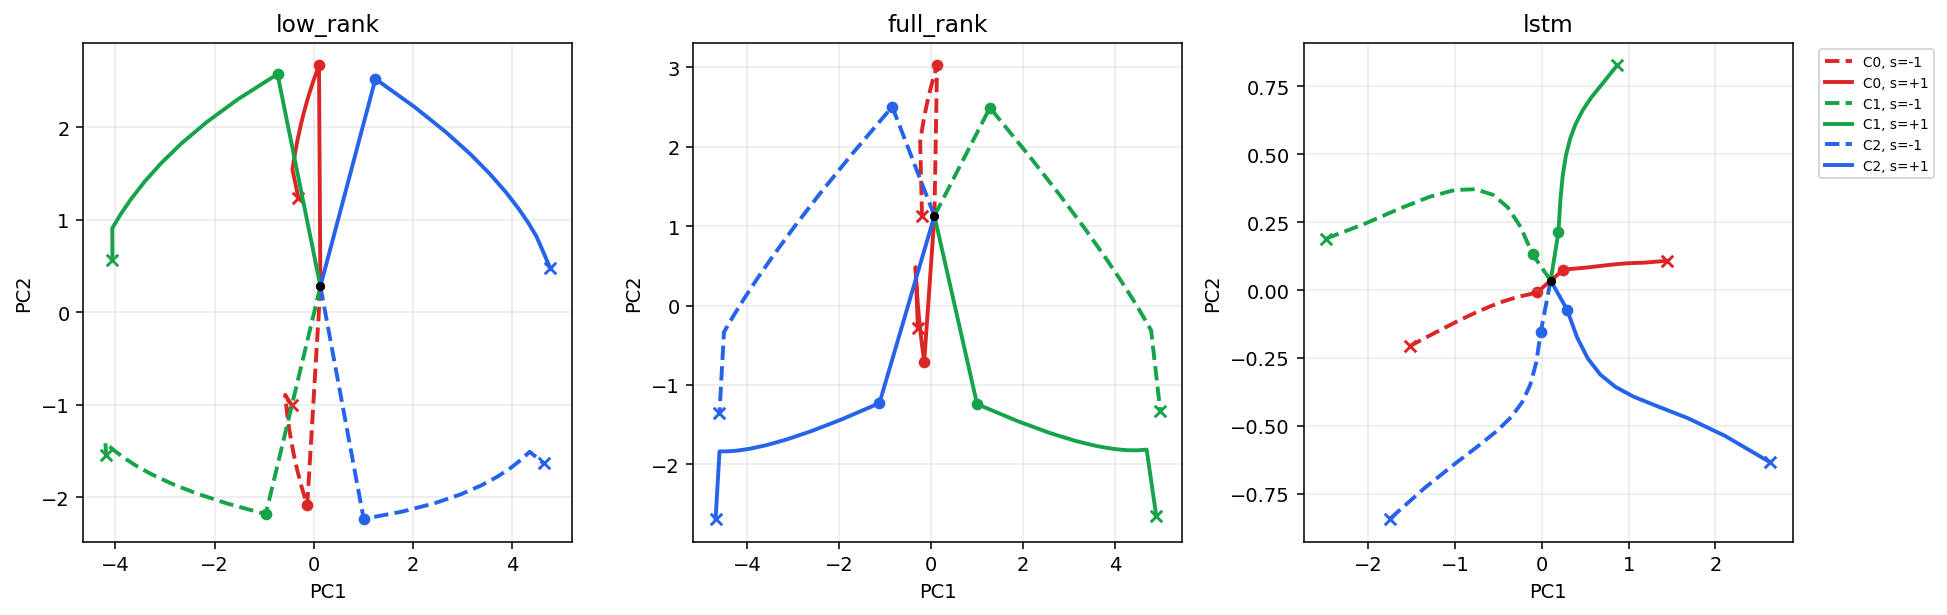

In [21]:
def get_initial_state_for_pca(model, model_name):
    """Return initial hidden state with shape [1, hidden]."""
    with T.no_grad():
        if model_name == "lstm":
            # LSTM starts from zero hidden state by default.
            return T.zeros(1, model.hidden_size).cpu()

        # Low-rank and full-rank RNNs use model.h0.
        return model.h0.detach().cpu()


def pca_project_with_h0(states, h0):
    """
    states: [batch, time, hidden]
    h0:     [1, hidden]

    PCA is fit on both h0 and all trajectory states, then h0 is returned
    in the same PC space as the trajectories.
    """
    X_states = states.reshape(-1, states.shape[-1]).numpy()
    X_h0 = h0.numpy()

    X_all = np.concatenate([X_h0, X_states], axis=0)
    X_mean = X_all.mean(axis=0, keepdims=True)
    X_centered = X_all - X_mean

    _, _, vt = np.linalg.svd(X_centered, full_matrices=False)
    pcs = vt[:2].T

    Z_all = X_centered @ pcs
    Z_h0 = Z_all[0]
    Z_states = Z_all[1:].reshape(states.shape[0], states.shape[1], 2)

    return Z_states, Z_h0


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=140)

for ax, (name, res) in zip(axes, results.items()):
    h0 = get_initial_state_for_pca(models[name], name)
    Z, Z_h0 = pca_project_with_h0(res["states"], h0)

    for context_id in range(3):
        for stimulus in (-1, 1):
            mask = (
                (contexts.cpu().numpy() == context_id)
                & (stimuli.cpu().numpy() == stimulus)
            )

            # Average repeated trials after projection.
            traj = Z[mask].mean(axis=0)

            # Prepend projected h0 as the pre-trial initial point.
            traj_with_h0 = np.vstack([Z_h0[None, :], traj])

            ax.plot(
                traj_with_h0[:, 0],
                traj_with_h0[:, 1],
                color=colors[context_id],
                ls=linestyles[stimulus],
                lw=2,
                label=f"C{context_id}, s={stimulus:+d}",
            )

            # h0 point
            ax.scatter(
                traj_with_h0[0, 0],
                traj_with_h0[0, 1],
                color="black",
                marker=".",
                s=45,
                zorder=5,
            )

            # first post-input state
            ax.scatter(
                traj_with_h0[1, 0],
                traj_with_h0[1, 1],
                color=colors[context_id],
                marker="o",
                s=25,
            )

            # final decision state
            ax.scatter(
                traj_with_h0[-1, 0],
                traj_with_h0[-1, 1],
                color=colors[context_id],
                marker="x",
                s=35,
            )

    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.25)

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(
    handles[:6],
    labels[:6],
    fontsize=7,
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


### 8.low-rank dynamic

## 8. Low-Rank-Only Analysis: Input Weight Geometry

Now we focus only on the low-rank RNN because its dynamics are simpler and more traceable. This analysis inspects `W_in`, the input-to-hidden matrix. Each column tells us how one input channel drives the hidden population:

`[stimulus, cond_0, cond_1, cond_2, go_cue]`

The heatmap shows all hidden-unit input weights. The corner plot shows pairwise relationships between input channels across hidden units. The selectivity count asks which input channel has the largest absolute incoming weight for each hidden unit.

W_in shape: (256, 5)
Columns: ['stimulus', 'cond_0', 'cond_1', 'cond_2', 'go_cue']


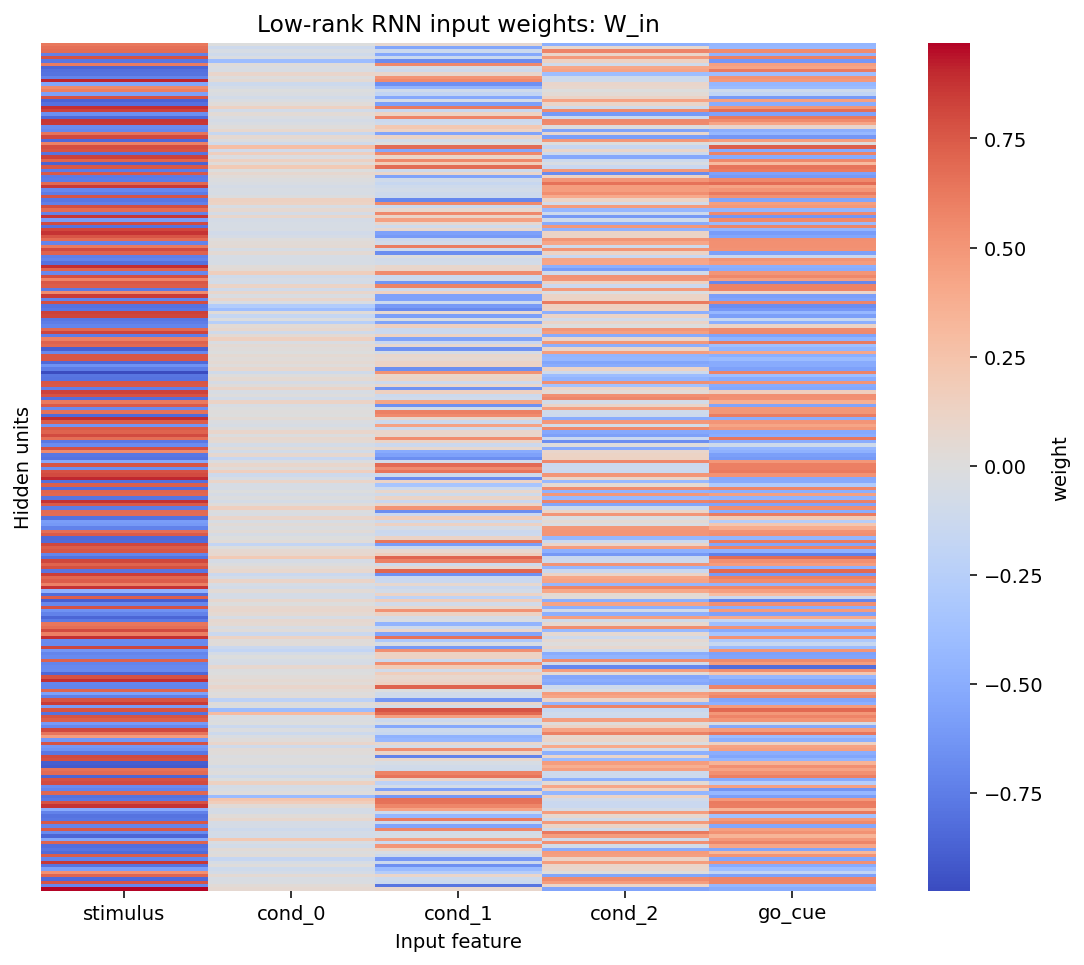

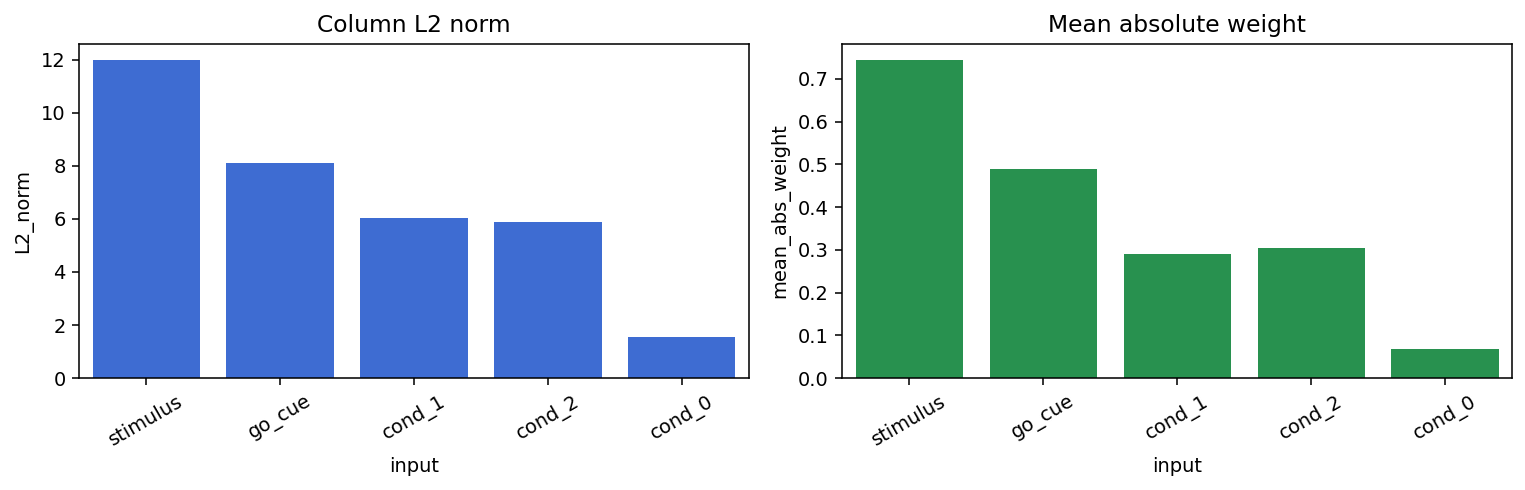

,input,L2_norm,mean_abs_weight
0,stimulus,12.011103,0.745389
4,go_cue,8.099195,0.488510
2,cond_1,6.021575,0.290515
3,cond_2,5.894720,0.303771
1,cond_0,1.540682,0.068192


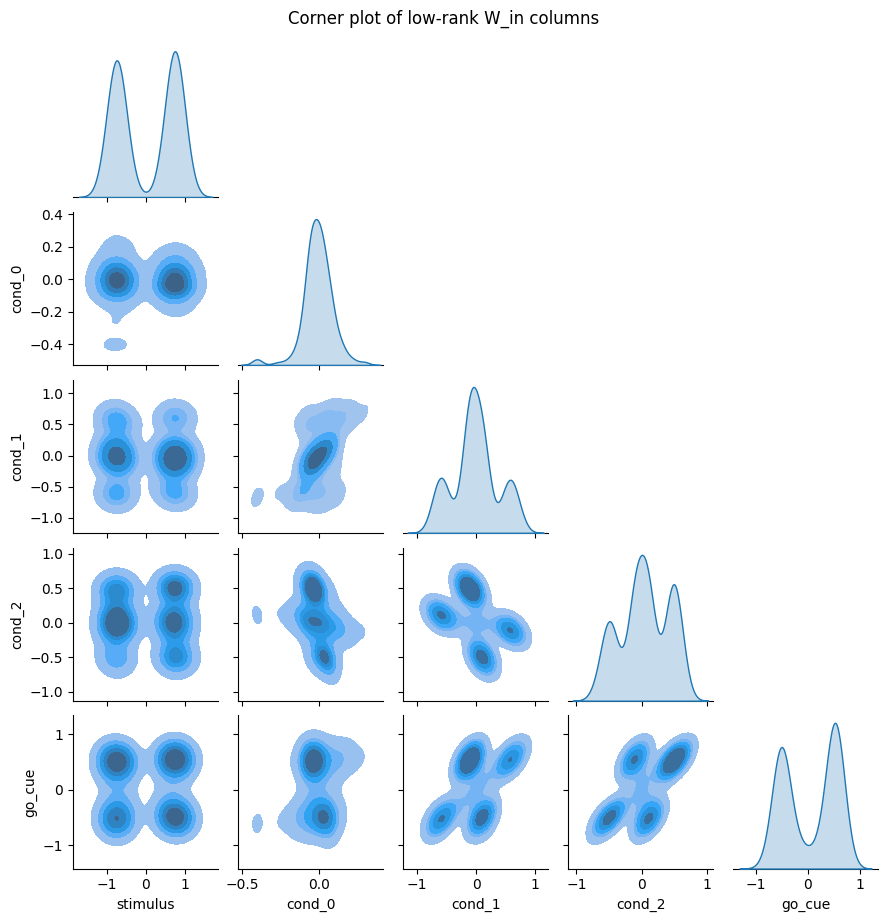

Selectivity distribution: largest absolute W_in column per hidden unit


,input,count,fraction
0,stimulus,249,0.972656
1,cond_0,0,0.000000
2,cond_1,4,0.015625
3,cond_2,1,0.003906
4,go_cue,2,0.007812


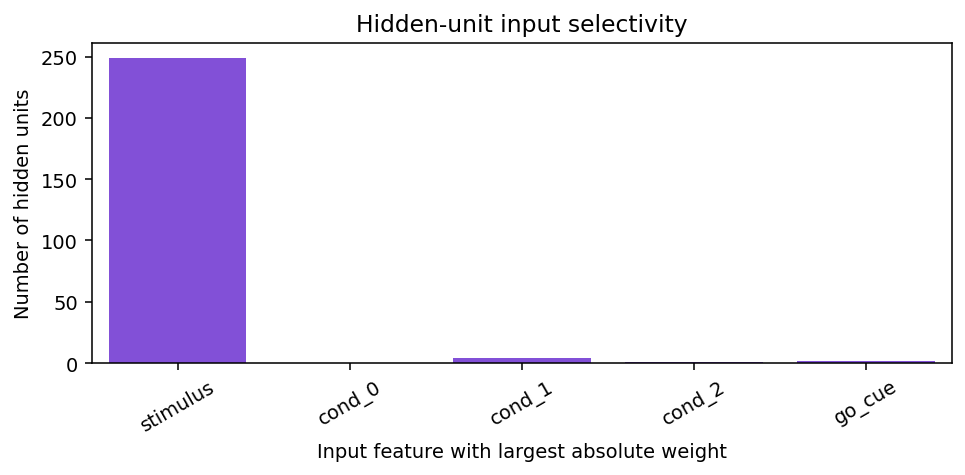

In [23]:
import seaborn as sns

LOW_RANK_COLUMN_NAMES = ["stimulus", "cond_0", "cond_1", "cond_2", "go_cue"]


def extract_low_rank_state_dict():
    """Return the trained low-rank state dict from the loaded checkpoint."""
    if "model_state_dict" in checkpoints["low_rank"]:
        return checkpoints["low_rank"]["model_state_dict"]
    if "state_dict" in checkpoints["low_rank"]:
        return checkpoints["low_rank"]["state_dict"]
    raise KeyError("Could not find low-rank model state dict in checkpoint.")


def analyze_low_rank_w_in(state_dict, column_names=LOW_RANK_COLUMN_NAMES):
    """Analyze input weights of the trained homework low-rank RNN."""
    if "W_in" not in state_dict:
        raise KeyError("Current homework low-rank model should contain W_in in its state dict.")

    W_in = state_dict["W_in"]
    if isinstance(W_in, T.Tensor):
        W_in = W_in.detach().cpu().numpy()

    if W_in.shape[1] != len(column_names):
        raise ValueError(f"Expected {len(column_names)} input columns, got W_in shape {W_in.shape}.")

    print("W_in shape:", W_in.shape)
    print("Columns:", column_names)

    # 1. Heatmap across hidden units and input features.
    plt.figure(figsize=(8, 7), dpi=140)
    sns.heatmap(
        W_in,
        cmap="coolwarm",
        center=0,
        xticklabels=column_names,
        yticklabels=False,
        cbar_kws={"label": "weight"},
    )
    plt.title("Low-rank RNN input weights: W_in")
    plt.xlabel("Input feature")
    plt.ylabel("Hidden units")
    plt.tight_layout()
    plt.show()

    # 2. Column norm summary.
    col_norms = np.linalg.norm(W_in, axis=0)
    col_abs_mean = np.mean(np.abs(W_in), axis=0)
    summary = pd.DataFrame({
        "input": column_names,
        "L2_norm": col_norms,
        "mean_abs_weight": col_abs_mean,
    }).sort_values("L2_norm", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), dpi=140)
    sns.barplot(data=summary, x="input", y="L2_norm", ax=axes[0], color="#2563eb")
    axes[0].set_title("Column L2 norm")
    axes[0].tick_params(axis="x", rotation=30)
    sns.barplot(data=summary, x="input", y="mean_abs_weight", ax=axes[1], color="#16a34a")
    axes[1].set_title("Mean absolute weight")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

    display(summary)

    # 3. Corner plot of hidden-unit input weights.
    df = pd.DataFrame(W_in, columns=column_names)
    g = sns.pairplot(
        data=df,
        diag_kind="kde",
        kind="kde",
        corner=True,
        height=1.8,
        plot_kws={"fill": True, "levels": 6, "thresh": 0.05},
    )
    g.fig.suptitle("Corner plot of low-rank W_in columns", y=1.02)
    plt.show()

    # 4. Selectivity: largest absolute input weight for each hidden unit.
    abs_w = np.abs(W_in)
    max_idx = np.argmax(abs_w, axis=1)
    unique, counts = np.unique(max_idx, return_counts=True)
    selectivity = pd.DataFrame({"input": column_names, "count": 0})
    for idx, count in zip(unique, counts):
        selectivity.loc[selectivity["input"] == column_names[idx], "count"] = int(count)
    selectivity["fraction"] = selectivity["count"] / W_in.shape[0]

    print("Selectivity distribution: largest absolute W_in column per hidden unit")
    display(selectivity)

    plt.figure(figsize=(7, 3.5), dpi=140)
    sns.barplot(data=selectivity, x="input", y="count", color="#7c3aed")
    plt.title("Hidden-unit input selectivity")
    plt.xlabel("Input feature with largest absolute weight")
    plt.ylabel("Number of hidden units")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return W_in, summary, selectivity


low_rank_state_dict = extract_low_rank_state_dict()
W_in_low_rank, W_in_summary, W_in_selectivity = analyze_low_rank_w_in(low_rank_state_dict)

## 9. Low-Rank-Only Analysis: Readout Overlap

This analysis uses the already-loaded `models["low_rank"]` object. It asks which hidden-space directions are most aligned with the readout vector `W_out`: direct input directions from `W_in`, and low-rank recurrent directions `m = U` and `n = V`.

In [ ]:
# Use the low-rank network already loaded earlier in the notebook.
low_rank_model = models["low_rank"]

W_in = low_rank_model.W_in.detach().cpu().numpy()      # [hidden, input_dim]
U = low_rank_model.U.detach().cpu().numpy()            # [hidden, rank]
V = low_rank_model.V.detach().cpu().numpy()            # [hidden, rank]
W_out = low_rank_model.W_out.detach().cpu().numpy()    # [1, hidden]
w_out = W_out[0]

input_names = ["stimulus", "cond_0", "cond_1", "cond_2", "go_cue"]


def cosine(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)


rows = []

# Overlap between readout and each input-to-hidden direction.
for i, name in enumerate(input_names):
    w_in_col = W_in[:, i]
    cos_val = cosine(w_out, w_in_col)
    rows.append({
        "direction": name,
        "group": "input W_in",
        "cosine": cos_val,
        "abs_cosine": abs(cos_val),
        "dot": float(np.dot(w_out, w_in_col)),
    })

# Overlap between readout and low-rank recurrent directions.
# In this model, recurrent contribution is (r @ V) @ U.T.
# U columns are output/recurrent directions m; V columns are selection directions n.
for r in range(U.shape[1]):
    m_r = U[:, r]
    n_r = V[:, r]

    cos_m = cosine(w_out, m_r)
    rows.append({
        "direction": f"m{r} = U[:, {r}]",
        "group": "recurrent m/U",
        "cosine": cos_m,
        "abs_cosine": abs(cos_m),
        "dot": float(np.dot(w_out, m_r)),
    })

    cos_n = cosine(w_out, n_r)
    rows.append({
        "direction": f"n{r} = V[:, {r}]",
        "group": "recurrent n/V",
        "cosine": cos_n,
        "abs_cosine": abs(cos_n),
        "dot": float(np.dot(w_out, n_r)),
    })

overlap_df = pd.DataFrame(rows).sort_values("abs_cosine", ascending=False)
display(overlap_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), dpi=140)

sns.barplot(
    data=overlap_df,
    x="direction",
    y="cosine",
    hue="group",
    dodge=False,
    ax=axes[0],
)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Signed overlap with W_out")
axes[0].set_ylabel("cosine similarity")
axes[0].set_xlabel("hidden-space direction")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=overlap_df,
    x="direction",
    y="abs_cosine",
    hue="group",
    dodge=False,
    ax=axes[1],
)
axes[1].set_title("Absolute overlap with W_out")
axes[1].set_ylabel("|cosine similarity|")
axes[1].set_xlabel("hidden-space direction")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()